# Data Science Lab on Smart Cities

## Decoding the Intersection between Ridesourcing Dependency and Socio-Demographic Vulnerability in the Chicago FUA

Research question: Is ridesourcing acting as a mobility equalizer or as a costly substitute for inadequate public transport in vulnerable peripheral areas of Chicago?

Analysis:
1. DATA 
2. CONSTRUCT INDICATORS: 
   - TNP Usage Intensity (TUI), 
   - Public Transport Accessibility (PTA), and 
   - Socio-Demographic Vulnerability Index (SDVI) 
3. ...

### 1. Data Sources: 

- CMAP Community Data Snapshots - https://services5.arcgis.com/LcMXE3TFhi1BSaCY/arcgis/rest/services/CommunityDataSnapshots_2015_2025_gdb/FeatureServer
DATA HUB link: https://datahub.cmap.illinois.gov/search?tags=community%2520data%2520snapshots

- Transportation Network Providers - Trips(Chicago Data Portal)
        - 2018 - 2022: https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2018-2022-/m6dm-c72p/data_preview
        - 2023 - 2024: https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2023-2024-/n26f-ihde/data_preview

- Boundaries - Community Areas (Chicago Data Portal)
https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6


### TNP USAGE INTENSITY (TUI)
TNP Usage Intensity measures the number of ridesourcing trips generated in a Community Area during a given time period, normalized by the resident population. Higher values indicate more TNP activity per resident. 
The index should be interpreted as usage intensity rather than dependency unless combined with indicators of public transport accessibility. 

$$TUI= \frac{TNP pickups_{i,m}}{population_{i,m}} *1000$$

where:
- i: community area
- m: month
- TNP pickups: number of ridesourcing trips startint in that community area
- Population: resident population in the community area


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from utils import (
    build_analysis_gdf,
    build_tui_map,
    compute_tui_correlations,
    compute_tui_index,
    load_all_cca_population,
    load_chicago_community_areas,
    load_vulnerability_data,
    plot_tui_index,
    plot_tui_vulnerability_maps,
    plot_tui_vulnerability_scatter,
    source_tnp_counts,
)


In [18]:
#TNP Usage Data - source via API  
url_2023_2024 = "https://data.cityofchicago.org/resource/n26f-ihde.json"
source_tnp_counts(url_2023_2024, "tnp_counts_2023-2024")

In [19]:
url_2018_2022 = "https://data.cityofchicago.org/resource/m6dm-c72p.json"
source_tnp_counts(url_2018_2022, "tnp_counts_2018-2022")

In [20]:
#aggregate tnp counts with population size
tnp_counts_2018_2022 = pd.read_csv("data/tnp_counts_2018-2022.csv")
tnp_counts_2023_2024 = pd.read_csv("data/tnp_counts_2023-2024.csv")
tnp_counts = pd.concat([tnp_counts_2018_2022, tnp_counts_2023_2024], ignore_index=True)
tnp_counts["month"] = pd.to_datetime(tnp_counts["month"])
tnp_counts["year"] = tnp_counts["month"].dt.year
tnp_counts = tnp_counts.rename(columns={"pickup_community_area": "community_area"})

population = load_all_cca_population("data")

df = pd.merge(tnp_counts, population, on=["community_area", "year"], how="left")

In [21]:
df = compute_tui_index(df)

In [22]:
df.to_csv("data/tui_index.csv", index=False)
df.head()

,month,community_area,n_trips,year,community_area_name,population,tui_index
0,2018-11-01,1,99221,2018,Rogers Park,55500.0,1787.765766
1,2018-11-01,2,71955,2018,West Ridge,73723.0,976.018339
2,2018-11-01,3,187550,2018,Uptown,56296.0,3331.497797
3,2018-11-01,4,89958,2018,Lincoln Square,41483.0,2168.550973
4,2018-11-01,5,104623,2018,North Center,34942.0,2994.190373


In [23]:
tui = pd.read_csv("data/tui_index.csv", parse_dates=["month"])
chicago_community_areas = load_chicago_community_areas(
    "data/Boundaries_-_Community_Areas_20260607.geojson"
)

tui_map_2018 = build_tui_map(chicago_community_areas, tui, year=2018)
tui_map_2024 = build_tui_map(chicago_community_areas, tui, year=2024)

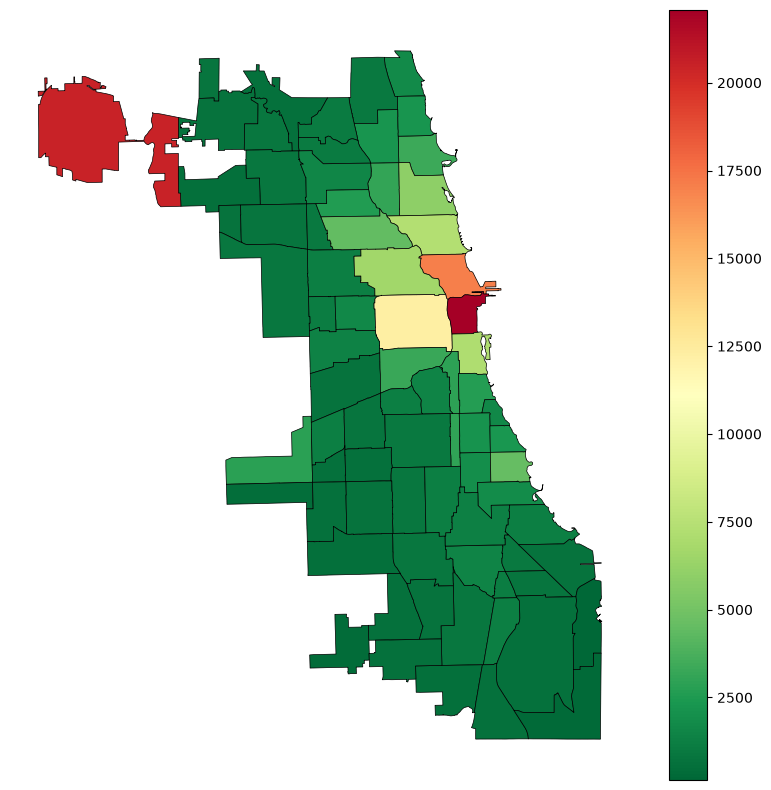

In [24]:
plot_tui_index(tui_map_2018, year=2018, add_labels=False)
plt.show()

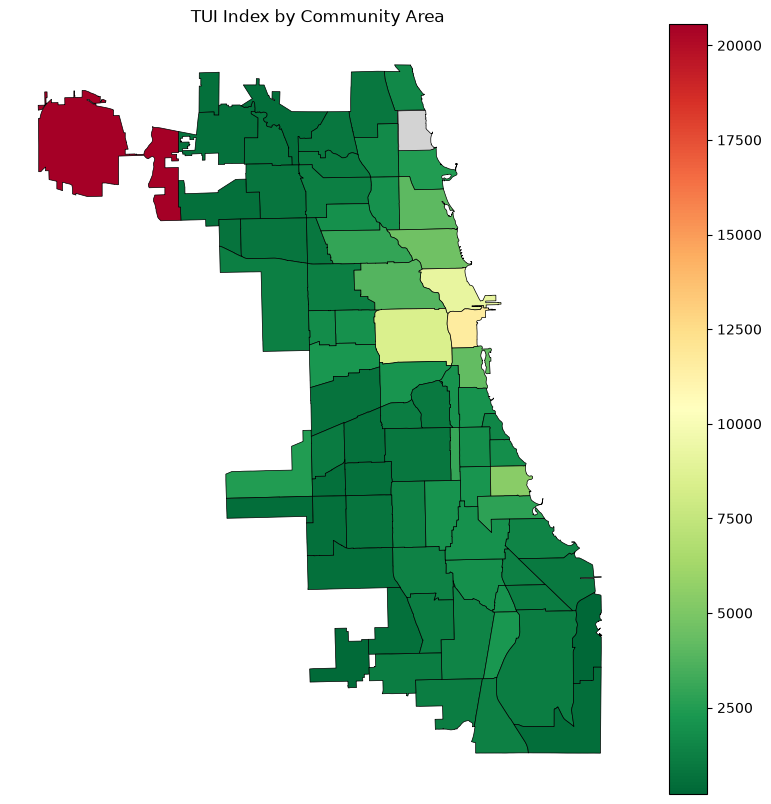

In [25]:
plot_tui_index(tui_map_2024, year=2024, add_labels=False)
plt.show()

### Socio-Demographic Vulnerability Index (SDVI)

Indice composito che combina il **Hardship Index** e il **reddito per capita** (Chicago Data Portal). Il reddito entra come disadvantage (`-income`): redditi più bassi implicano maggiore vulnerabilità. Valori SDVI più alti indicano maggiore vulnerabilità socio-demografica.

Il **CCVI** resta disponibile come indicatore ausiliario di vulnerabilità sanitaria, ma non entra nel calcolo di SDVI.

**Nota metodologica:** la Community Area 76 (O'Hare) è esclusa dall'analisi perché hub di trasporto outlier.

In [28]:
# dipendenze analisi SDVI: scipy, seaborn (vedi requirements.txt)


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
vulnerability = load_vulnerability_data("data")
analysis_gdf = build_analysis_gdf(tui_map_2024, vulnerability)

print(f"Community Areas in analysis (excl. O'Hare): {len(analysis_gdf)}")
analysis_gdf[[
    "community_area", "community_area_name", "tui_index",
    "hardship_index", "per_capita_income", "sdvi", "ccvi_score",
]].head()

Community Areas in analysis (excl. O'Hare): 75


,community_area,community_area_name,tui_index,hardship_index,ccvi_score,hsvi
0,1,ROGERS PARK,1589.021917,39.0,30.9,-0.426475
1,2,WEST RIDGE,872.629786,46.0,36.0,-0.133205
2,3,UPTOWN,2516.201448,20.0,24.4,-0.975891
3,4,LINCOLN SQUARE,1680.655769,17.0,15.0,-1.343862
4,5,NORTH CENTER,1983.218853,6.0,4.0,-1.904987


=== Correlazione di Pearson ===


,tui_index,hardship_index,ccvi_score,hsvi
tui_index,1.000,-0.385,-0.515,-0.472
hardship_index,-0.385,1.000,0.809,0.952
ccvi_score,-0.515,0.809,1.000,0.950
hsvi,-0.472,0.952,0.950,1.000



=== Correlazione di Spearman ===


,tui_index,hardship_index,ccvi_score,hsvi
tui_index,1.000,-0.111,-0.255,-0.174
hardship_index,-0.111,1.000,0.786,0.955
ccvi_score,-0.255,0.786,1.000,0.925
hsvi,-0.174,0.955,0.925,1.000



TUI vs HSVI: Pearson r=-0.472 (p=0.0000), Spearman rho=-0.174 (p=0.1344)

TUI vs Hardship Index: Pearson r=-0.385 (p=0.0007), Spearman rho=-0.111 (p=0.3409)

TUI vs CCVI: Pearson r=-0.515 (p=0.0000), Spearman rho=-0.255 (p=0.0274)


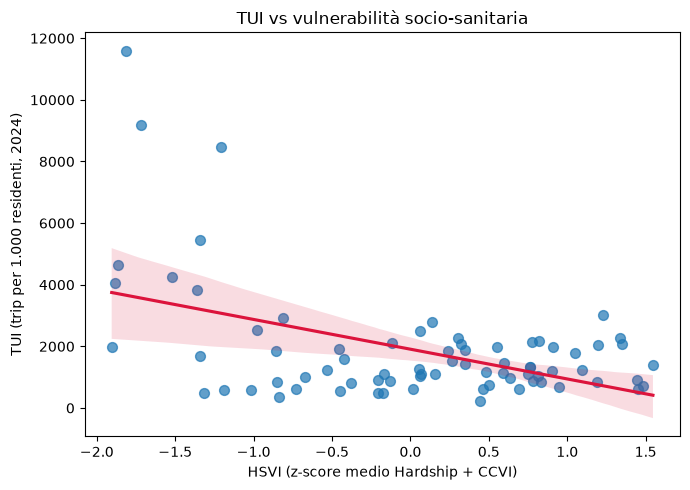

In [30]:
pearson, spearman, tests = compute_tui_correlations(analysis_gdf)

print("=== Correlazione di Pearson ===")
display(pearson.round(3))

print("\n=== Correlazione di Spearman ===")
display(spearman.round(3))

for _, row in tests.iterrows():
    print(
        f"\nTUI vs {row['indicator']}: "
        f"Pearson r={row['pearson_r']:.3f} (p={row['pearson_p']:.4f}), "
        f"Spearman rho={row['spearman_rho']:.3f} (p={row['spearman_p']:.4f})"
    )

plot_tui_vulnerability_scatter(analysis_gdf, year=2024)
plt.tight_layout()
plt.show()

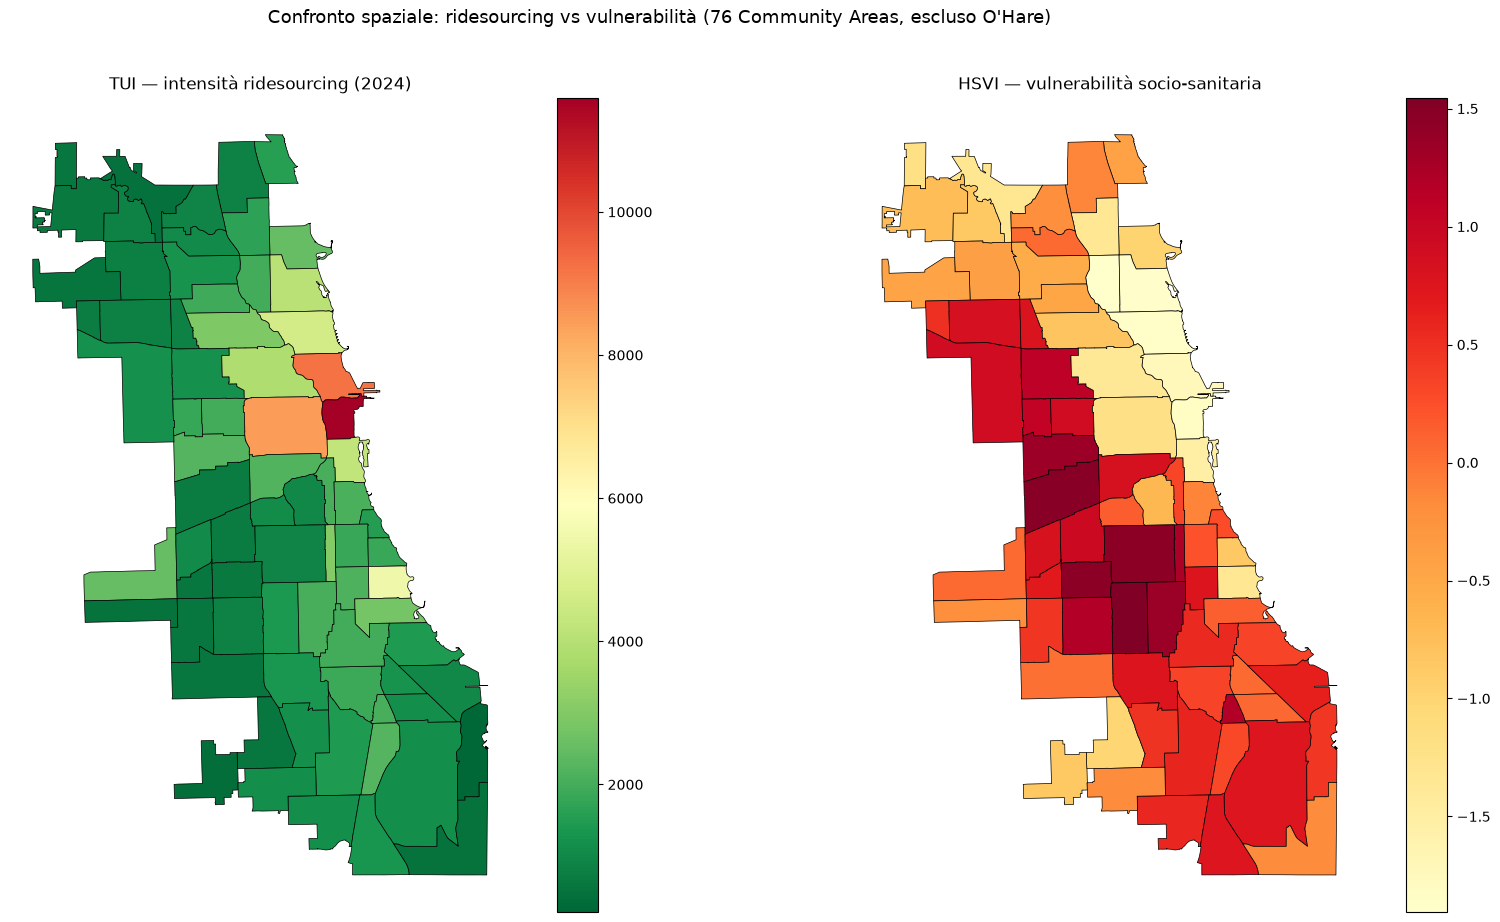

In [31]:
plot_tui_vulnerability_maps(analysis_gdf, year=2024)
plt.show()